# EDA

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import yaml
import datetime

current_time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(current_time)

2025-05-11 18:34:49


In [3]:
import numpy as np
import os
import pandas as pd
import random

from src.electrical_signature_frequencies import ANOMALY_FREQS
from src.anomaly_injector import GaussianPeakInjector, NoiseInjector, CompositeAnomalyInjector
import matplotlib.pyplot as plt

import torch

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set device 
device: str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)
print("Using device:", device)

Using device: mps


## Load Data

In [4]:
from src.data_pipeline import create_metadata_df, load_measurement

In [5]:
state2name = {
    1: "rotor bar defect",  # Rotor cage break
    2: "normal",
    3: "bearing defect",
    4: "inter-turn short circuits"  # Stator inter-turn short-circuit
}

# Create metadata DataFrame
base_dir = "../dataset/engine_2"

path2metadata = os.path.join(base_dir, 'metadata.csv')
if os.path.isfile(path2metadata):
    metadata_df = pd.read_csv(os.path.join(path2metadata))
    metadata_df.set_index('measurement_id', inplace=True)
else:
    metadata_df = create_metadata_df(base_dir, state2name)
    metadata_df.to_csv(path2metadata)

In [6]:
metadata_df

,base_id,experiment,state,load_condition,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,,,
1727864902_1,1727864902,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864862_1,1727864862,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864642_1,1727864642,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864722_1,1727864722,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
1727864522_1,1727864522,experiment_1,bearing defect,80,1,16384,../dataset/engine_2/experiment_1/current/3rd_l...,../dataset/engine_2/engine.yml
...,...,...,...,...,...,...,...,...
1727784570_2,1727784570,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784410_2,1727784410,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml
1727784610_2,1727784610,experiment_1,rotor bar defect,40,2,16384,../dataset/engine_2/experiment_1/current/1st_l...,../dataset/engine_2/engine.yml


In [7]:
# For each base_id we have 3 phases:
(metadata_df.reset_index().groupby('base_id')['measurement_id'].count() != 3).sum()

np.int64(0)

In [8]:
fault_types_available = [state for state in metadata_df['state'].unique() if state != 'normal']

print('Fault Types Available:')
print(', '.join(fault_types_available))

Fault Types Available:
bearing defect, inter-turn short circuits, rotor bar defect


In [9]:
# Load a specific measurement by its measurement_id

# For _3 there is a missing first value
specific_measurement_id = '1727864902_3'
specific_measurement_df = load_measurement(specific_measurement_id, metadata_df)

print("Measurement Metadata:\n", metadata_df.loc[specific_measurement_id])

print('\nDataFrame:\n', specific_measurement_df)

Measurement Metadata:
 base_id                                                    1727864902
experiment                                               experiment_1
state                                                  bearing defect
load_condition                                                     80
phase                                                               3
num_observations                                                16384
file_path           ../dataset/engine_2/experiment_1/current/3rd_l...
engine_cfg_path                        ../dataset/engine_2/engine.yml
Name: 1727864902_3, dtype: object

DataFrame:
               Current
Time                 
0.000000          NaN
0.244141     0.294649
0.488281     0.051620
0.732422    -0.251374
0.976562    -0.546743
...               ...
3998.779297 -2.241764
3999.023438 -2.428181
3999.267578 -2.576180
3999.511719 -2.732547
3999.755859 -2.872629

[16384 rows x 1 columns]


### Signal Visualization

In [10]:
import plotly.express as px

fig = px.line(
    specific_measurement_df,
    x=specific_measurement_df.index,
    y='Current',
    title=f'Current Signal Over Time. ID: {specific_measurement_id}',
    labels={'x': 'Time, ms', 'Current': 'Current'},
    template='plotly_white'
)

fig.update_layout(
    xaxis_title="Time, ms",
    yaxis_title="Current"
)

fig.show()

## Load Engine Configuration and Set Parameters

In [11]:
# Load training parameters from train.yml
with open("../training_configs/train-engine-2.yml", "r") as f:
    train_params = yaml.safe_load(f)

# Processing Parameters
f_sampling = train_params["processing_parameters"]["f_sampling"]
shift = train_params["processing_parameters"]["shift"]
segment_length = train_params["processing_parameters"]["segment_length"]
cutoff_freq = train_params["processing_parameters"]["cutoff_freq"]
peak_type = train_params["processing_parameters"]["peak_type"]
peak_segment = train_params["processing_parameters"]["peak_segment"]
amplitude_range = tuple(train_params["processing_parameters"]["amplitude_range"])
sigma_range = tuple(train_params["processing_parameters"]["sigma_range"])
noise_factor = train_params["processing_parameters"]["noise_factor"]

# Training Parameters
num_epochs_binary = train_params["training_parameters"]["num_epochs_binary"]
num_epochs_multi = train_params["training_parameters"]["num_epochs_multi"]

# Data Parameters
batch_size = train_params["data_parameters"]["batch_size"]

# Dataset Parameters
normalization_method = train_params["dataset_parameters"]["normalization_method"]

train_params

{'processing_parameters': {'f_sampling': 4098,
  'shift': 20,
  'segment_length': 10000,
  'cutoff_freq': 250,
  'peak_type': 'gaussian',
  'peak_segment': 10,
  'amplitude_range': [0.5, 20.0],
  'sigma_range': [0.5, 1.5],
  'noise_factor': 0.0,
  'include_negative_peaks': True,
  'random_peak_position': True,
  'fault_types_to_use': ['inter-turn short circuits', 'rotor bar defect'],
  'loads_to_use': [100],
  'phases_to_use': [1]},
 'training_parameters': {'num_epochs_binary': 20, 'num_epochs_multi': 20},
 'data_parameters': {'batch_size': 512},
 'dataset_parameters': {'test_size': 0.3,
  'val_size': 0.2,
  'normalization_method': 'min-max'}}

In [12]:
path2engine_cfg = os.path.join(base_dir, 'engine.yml')

# Load Engine Configuration
with open(path2engine_cfg, 'r') as f:
    engine_config = yaml.safe_load(f)

engine_config

{'engine': {'motor_model': 'АИP 80B4 IM1081',
  'power': 1.5,
  'rpm': 1390,
  'voltage': '380V/50Hz',
  'efficiency': 78,
  'nominal_current': 6.39,
  'power_factor': 0.79,
  'bearings': '6204'},
 'mcsa': {'f1': 50,
  'f_sampling': 4098,
  's': 0.073,
  'R_s': None,
  'p': 2,
  'f_r': 23.17,
  'n': 8,
  'beta': 0,
  'D_pit': 34.5,
  'D_ball': 7.94}}

In [13]:
MCSA_cfg = {
    'rotor bar defect': {
        'engine_config': engine_config['mcsa'],
        'n_range': range(1, 4)
        },
    'inter-turn short circuits': {
        'engine_config': engine_config['mcsa'],
        'k_range': range(1, 4, 2), 
        'm_range': range(0, 2)
        },
    'bearing defect': {
        'engine_config': engine_config['mcsa']
        },
}

fault_freqs = {
    fault_type: ANOMALY_FREQS[fault_type](**MCSA_cfg[fault_type]) for fault_type in fault_types_available
}

In [14]:
# Instantiate the Gaussian injector
gaussian_injector = GaussianPeakInjector(
    peak_segment=peak_segment,
    amplitude_range=amplitude_range,
    sigma_range=sigma_range
)

# Instantiate the Noise injector
noise_injector = NoiseInjector(noise_factor=noise_factor)

# Combine the injectors
composite_injector = CompositeAnomalyInjector({
    'peak-anomaly': gaussian_injector,
    'noise': noise_injector
})

## Apply Preprocessing to one observation

In [15]:
# Choose a measurement of normal engine
sample = metadata_df[metadata_df['state'] == 'normal'].iloc[0]
sample

base_id                                                    1727791012
experiment                                               experiment_1
state                                                          normal
load_condition                                                    100
phase                                                               1
num_observations                                                16384
file_path           ../dataset/engine_2/experiment_1/current/2nd_l...
engine_cfg_path                        ../dataset/engine_2/engine.yml
Name: 1727791012_1, dtype: object

In [16]:
# Load corresponding dataframe
df = load_measurement(sample.name, metadata_df)
df

,Current
Time,
0.000000,2.347748
0.244141,2.183217
0.488281,1.976231
0.732422,1.743942
0.976562,1.511428
...,...
3998.779297,-1.632223
3999.023438,-1.903840
3999.267578,-2.114818


In [17]:
from src.data_pipeline import segment_signal

# Segment the time-series data (dropna cause phase 3 has a missing value)
segments = segment_signal(
    df['Current'].dropna().values, 
    segment_length=segment_length, 
    step=shift, 
    apply_window=False
)

print(f'Shape: {segments.shape[0]} segments of size {segments.shape[1]}')

Shape: 320 segments of size 10000


In [23]:
from src.data_pipeline import perform_fft_on_segments

# Perform FFT on each segment
fft_segments, freqs = perform_fft_on_segments(
    segments, 
    f_sampling, 
    db=True, 
    cutoff_freq=cutoff_freq
)

In [24]:
print(f'Shape: {fft_segments.shape[0]} segments of size {fft_segments.shape[1]}')

Shape: 320 segments of size 611


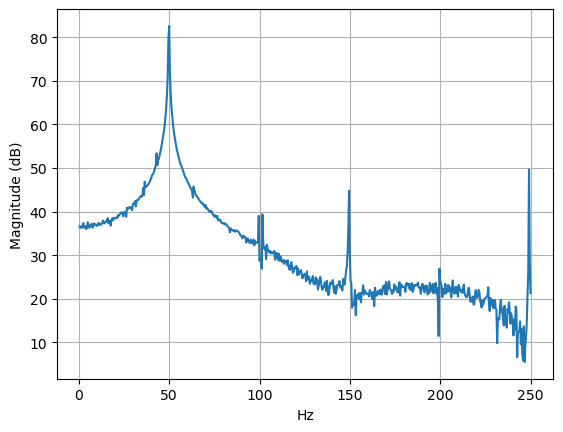

In [35]:
# Preprocessed signal visualization

idx = 0  # segment_index
plt.plot(freqs[1:], fft_segments[idx, 1:])   # skip bin 0
plt.xlabel("Hz")
plt.ylabel("Magnitude (dB)")
plt.grid()

In [27]:
index_with_max_amplitude = np.argmax(fft_segments[0])

print(f'Max amplitude index: {index_with_max_amplitude}. Corresponding frequency: {freqs[index_with_max_amplitude]}')

Max amplitude index: 122. Corresponding frequency: 49.9956


## Apply SGDA to one segment

In [36]:
# Pick a random fault type
chosen_fault = random.choice(fault_types_available)

print(f'Chosen fault: {chosen_fault}. Corresponding fault frequencies: {fault_freqs[chosen_fault]}')

Chosen fault: rotor bar defect. Corresponding fault frequencies: [28.1, 35.4, 42.7, 57.3, 64.6, 71.9]


In [37]:
# Inject fault to one segment
fft_segment = fft_segments[0]  # Choose one segment
modified_fft_segment = composite_injector.inject(fft_segment, freqs, fault_freqs[chosen_fault])

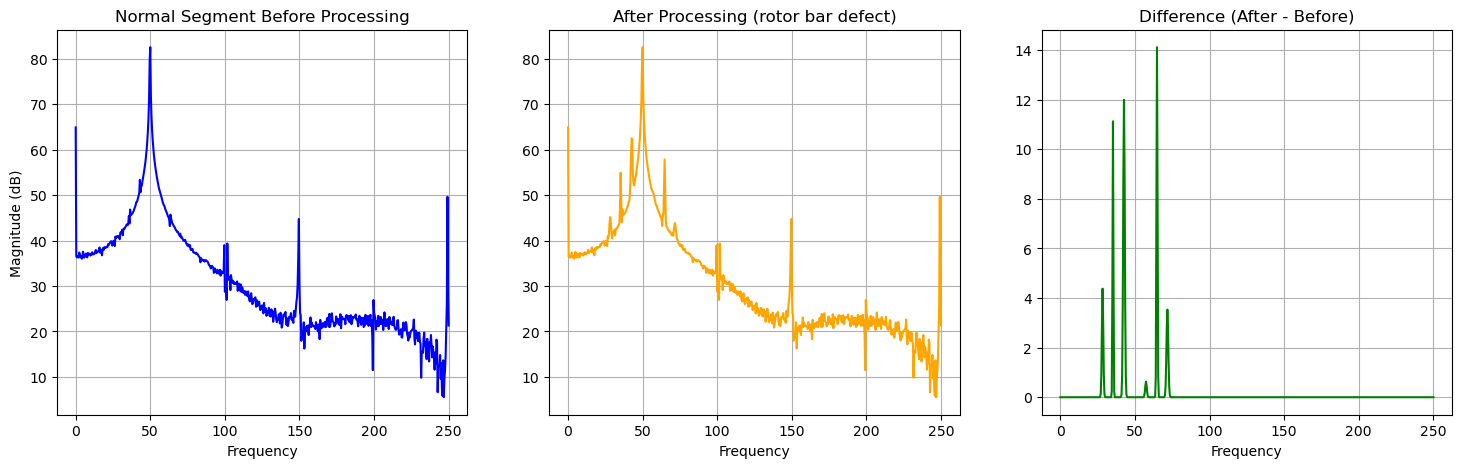

In [38]:
# Visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(freqs, fft_segment, color='blue')
axs[0].set_title("Normal Segment Before Processing")
axs[0].set_xlabel("Frequency")
axs[0].set_ylabel("Magnitude (dB)")
axs[0].grid(True)

axs[1].plot(freqs, modified_fft_segment, color='orange')
axs[1].set_title(f"After Processing ({chosen_fault})")
axs[1].set_xlabel("Frequency")
axs[1].grid(True)

difference = modified_fft_segment - fft_segment
axs[2].plot(freqs, difference, color='green')
axs[2].set_title("Difference (After - Before)")
axs[2].set_xlabel("Frequency")
axs[2].grid(True)

## Data for Models

- For each base index 3 measurement are given (with unique measurement ids)
- Each measurement is undergone a segmentation -> $N$ segments
- Segments is the atomic object of the dataset

* **`segments.npy`** – a dense array holding every preprocessed segment.  
* **`segments_metadata.csv`** – a row-per-segment table that keeps the foreign-key back to the original measurement row in **`metadata_df`** and the label(s) needed for binary or multiclass training.  

The key is the tuple **`(measurement_id, segment_idx)`**; you never lose the link between a segment and its parent measurement.

The segment-level schema

| column                | dtype    | description                                                            |
|-----------------------|----------|------------------------------------------------------------------------|
| `measurement_id`      | string   | index from your existing `metadata_df`                                 |
| `segment_idx`         | int      | 0…N-1 inside that measurement                                          |
| `start_time`          | float    | first timestamp in the segment (ms)                                    |
| `end_time`            | float    | last timestamp in the segment (ms)                                     |
| `state`               | string   | e.g. `"normal"`, `"rotor bar defect"`                                  |
| `binary_label`        | int8     | 0 = normal, 1 = fault                                                  |
| `multiclass_label`    | string   | equals `state`                                                         |
| `phase`               | int8     | copied from `metadata_df` (1, 2, 3)                                    |
| `load_condition`      | string   | copied from `metadata_df`                                              |
| `experiment`          | string   | copied from `metadata_df`                                              |


In [39]:
from typing import Tuple, List

import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from src.data_pipeline import segment_signal, perform_fft_on_segments

def preprocessing(
    metadata_df: pd.DataFrame,
    out_dir: str,
    segment_length: int,
    step: int,
    f_sampling: int,
    cutoff_freq: int,
    apply_window: bool = False,
    db: bool = True,
) -> Tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """
    Slice every measurement into fixed-length FFT segments
    and build a segment-level metadata table.

    Parameters
    ----------
    metadata_df : DataFrame
        The measurement-level table returned by `create_metadata_df`.
        MUST contain columns  ['state', 'phase', 'load_condition', 'experiment']
        and be indexed by 'measurement_id'.
    out_dir : str
        Directory where segments.npy and segments_metadata.csv are stored.
    segment_length, step, f_sampling, cutoff_freq, apply_window, db
        Usual DSP hyper-parameters (see notebook).

    Returns
    -------
    segments : np.ndarray
        Shape (total_segments, segment_length)
    seg_meta_df : DataFrame
        Multi-indexed by (measurement_id, segment_idx)
    """
    seg_meta_rows: List[dict] = []
    seg_arrays: List[np.ndarray] = []

    for m_id, meta in tqdm(metadata_df.iterrows(),
                           total=len(metadata_df),
                           desc="pre-processing"):
        # 1) load measurement
        df = load_measurement(m_id, metadata_df)
        current = df["Current"].dropna().values

        # 2) slice time-domain windows
        windows = segment_signal(
            current,
            segment_length=segment_length,
            step=step,
            apply_window=apply_window,
        )

        # 3) FFT
        fft_windows, freqs = perform_fft_on_segments(
            windows,
            f_sampling=f_sampling,
            cutoff_freq=cutoff_freq,
            db=db,
        )

        # 4) per-segment rows
        n_segments = fft_windows.shape[0]
        for s_idx in range(n_segments):
            start_t = df.index[s_idx * step]
            end_t   = df.index[s_idx * step + segment_length - 1]
            seg_meta_rows.append({
                "measurement_id": m_id,
                "segment_idx":    s_idx,
                "start_time":     float(start_t),
                "end_time":       float(end_t),
                "state":          meta["state"],
                "binary_label":   0 if meta["state"] == "normal" else 1,
                "multiclass_label": meta["state"],
                "phase":          int(meta["phase"]),
                "load_condition": meta["load_condition"],
                "experiment":     meta["experiment"],
            })
        seg_arrays.append(fft_windows.astype(np.float32))

    # 5) concat & persist
    segments = np.vstack(seg_arrays)  # (tot_segments, segment_length)
    seg_meta_df = (
        pd.DataFrame(seg_meta_rows)
          .set_index(["measurement_id", "segment_idx"])
    )

    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "segments.npy"), segments)
    np.save(os.path.join(out_dir, "freqs.npy"), freqs)
    seg_meta_df.to_csv(os.path.join(out_dir, "segments_metadata.csv"))

    return segments, seg_meta_df, freqs

In [ ]:
segments, seg_meta_df, freqs = preprocessing(
    metadata_df      = metadata_df,
    out_dir          = base_dir,
    segment_length   = segment_length,
    step             = shift,
    f_sampling       = f_sampling,
    cutoff_freq      = cutoff_freq,
    apply_window     = False,
    db               = True
)

pre-processing:   0%|          | 0/1440 [00:00<?, ?it/s]

## Study Segments

In [40]:
from src.visualization import plot_fault_freqs, plot_mean_std, plot_structural_deviations, filter_segments

In [58]:
base_dir = "../dataset/engine_2"

segments_path   = f"{base_dir}/segments.npy"
meta_path       = f"{base_dir}/segments_metadata.csv"
freqs_path      = f"{base_dir}/freqs.npy"

# Load
segments    = np.load(segments_path, mmap_mode="r")            # shape (n_segments, n_freq_bins)
seg_meta    = pd.read_csv(meta_path, index_col=["measurement_id", "segment_idx"])
freqs       = np.load(freqs_path)                              # length = n_freq_bins

# Classes
states = seg_meta['state'].unique()

# Load Engine Configuration
path2engine_cfg = os.path.join(base_dir, 'engine.yml')
with open(path2engine_cfg, 'r') as f:
    engine_config = yaml.safe_load(f)

# MCSA
fault_types_available = [state for state in states if state != 'normal']

MCSA_cfg = {
    'rotor bar defect': {
        'engine_config': engine_config['mcsa'],
        'n_range': range(1, 4)
        },
    'inter-turn short circuits': {
        'engine_config': engine_config['mcsa'],
        'k_range': range(1, 4, 2), 
        'm_range': range(0, 2)
        },
    'bearing defect': {
        'engine_config': engine_config['mcsa']
        },
}

fault_freqs = {
    fault_type: ANOMALY_FREQS[fault_type](**MCSA_cfg[fault_type]) for fault_type in fault_types_available
}

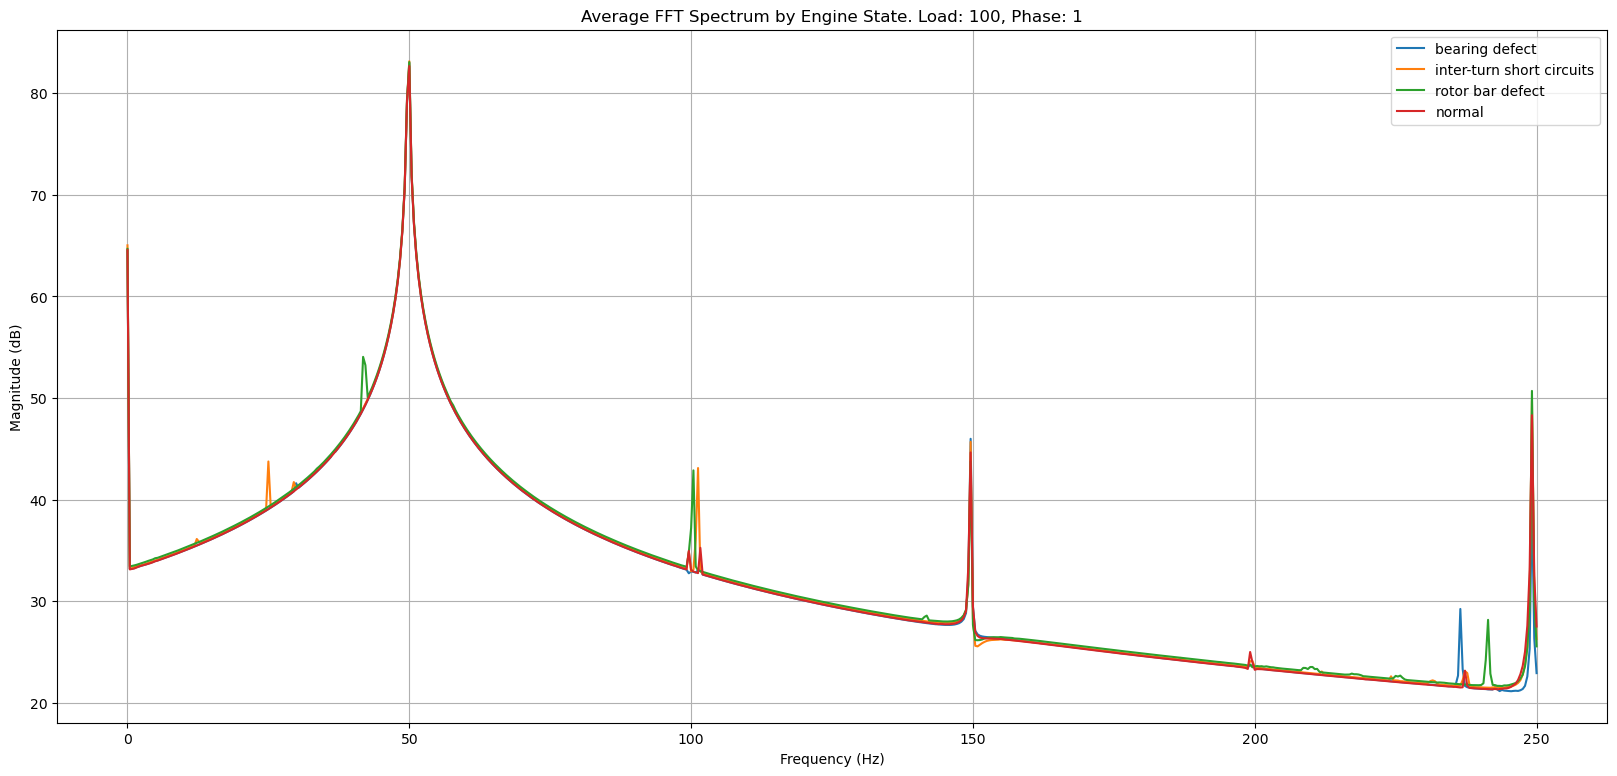

In [59]:
loads = [100]
phases = [1]

mean_filtered_spectra = {state: segments[filter_segments(seg_meta, [state], loads, phases).values].mean(axis=0) for state in states}

# Overlay plot
plt.figure(figsize=(20, 9))
for state, spec in mean_filtered_spectra.items():
    plt.plot(freqs, spec, label=state)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title(f"Average FFT Spectrum by Engine State. Load: {', '.join(str(x) for x in loads)}, Phase: {', '.join(str(x) for x in phases)}")
plt.legend()
plt.grid()
plt.show()

In the image above we see average FFT spectrum for all target classes. It's possible to notice that each of them has special frequency areas with theirs own amplitudes. Combinination of these areas can be seen as "signatures" corresponding to particular class making it outstanding among others.

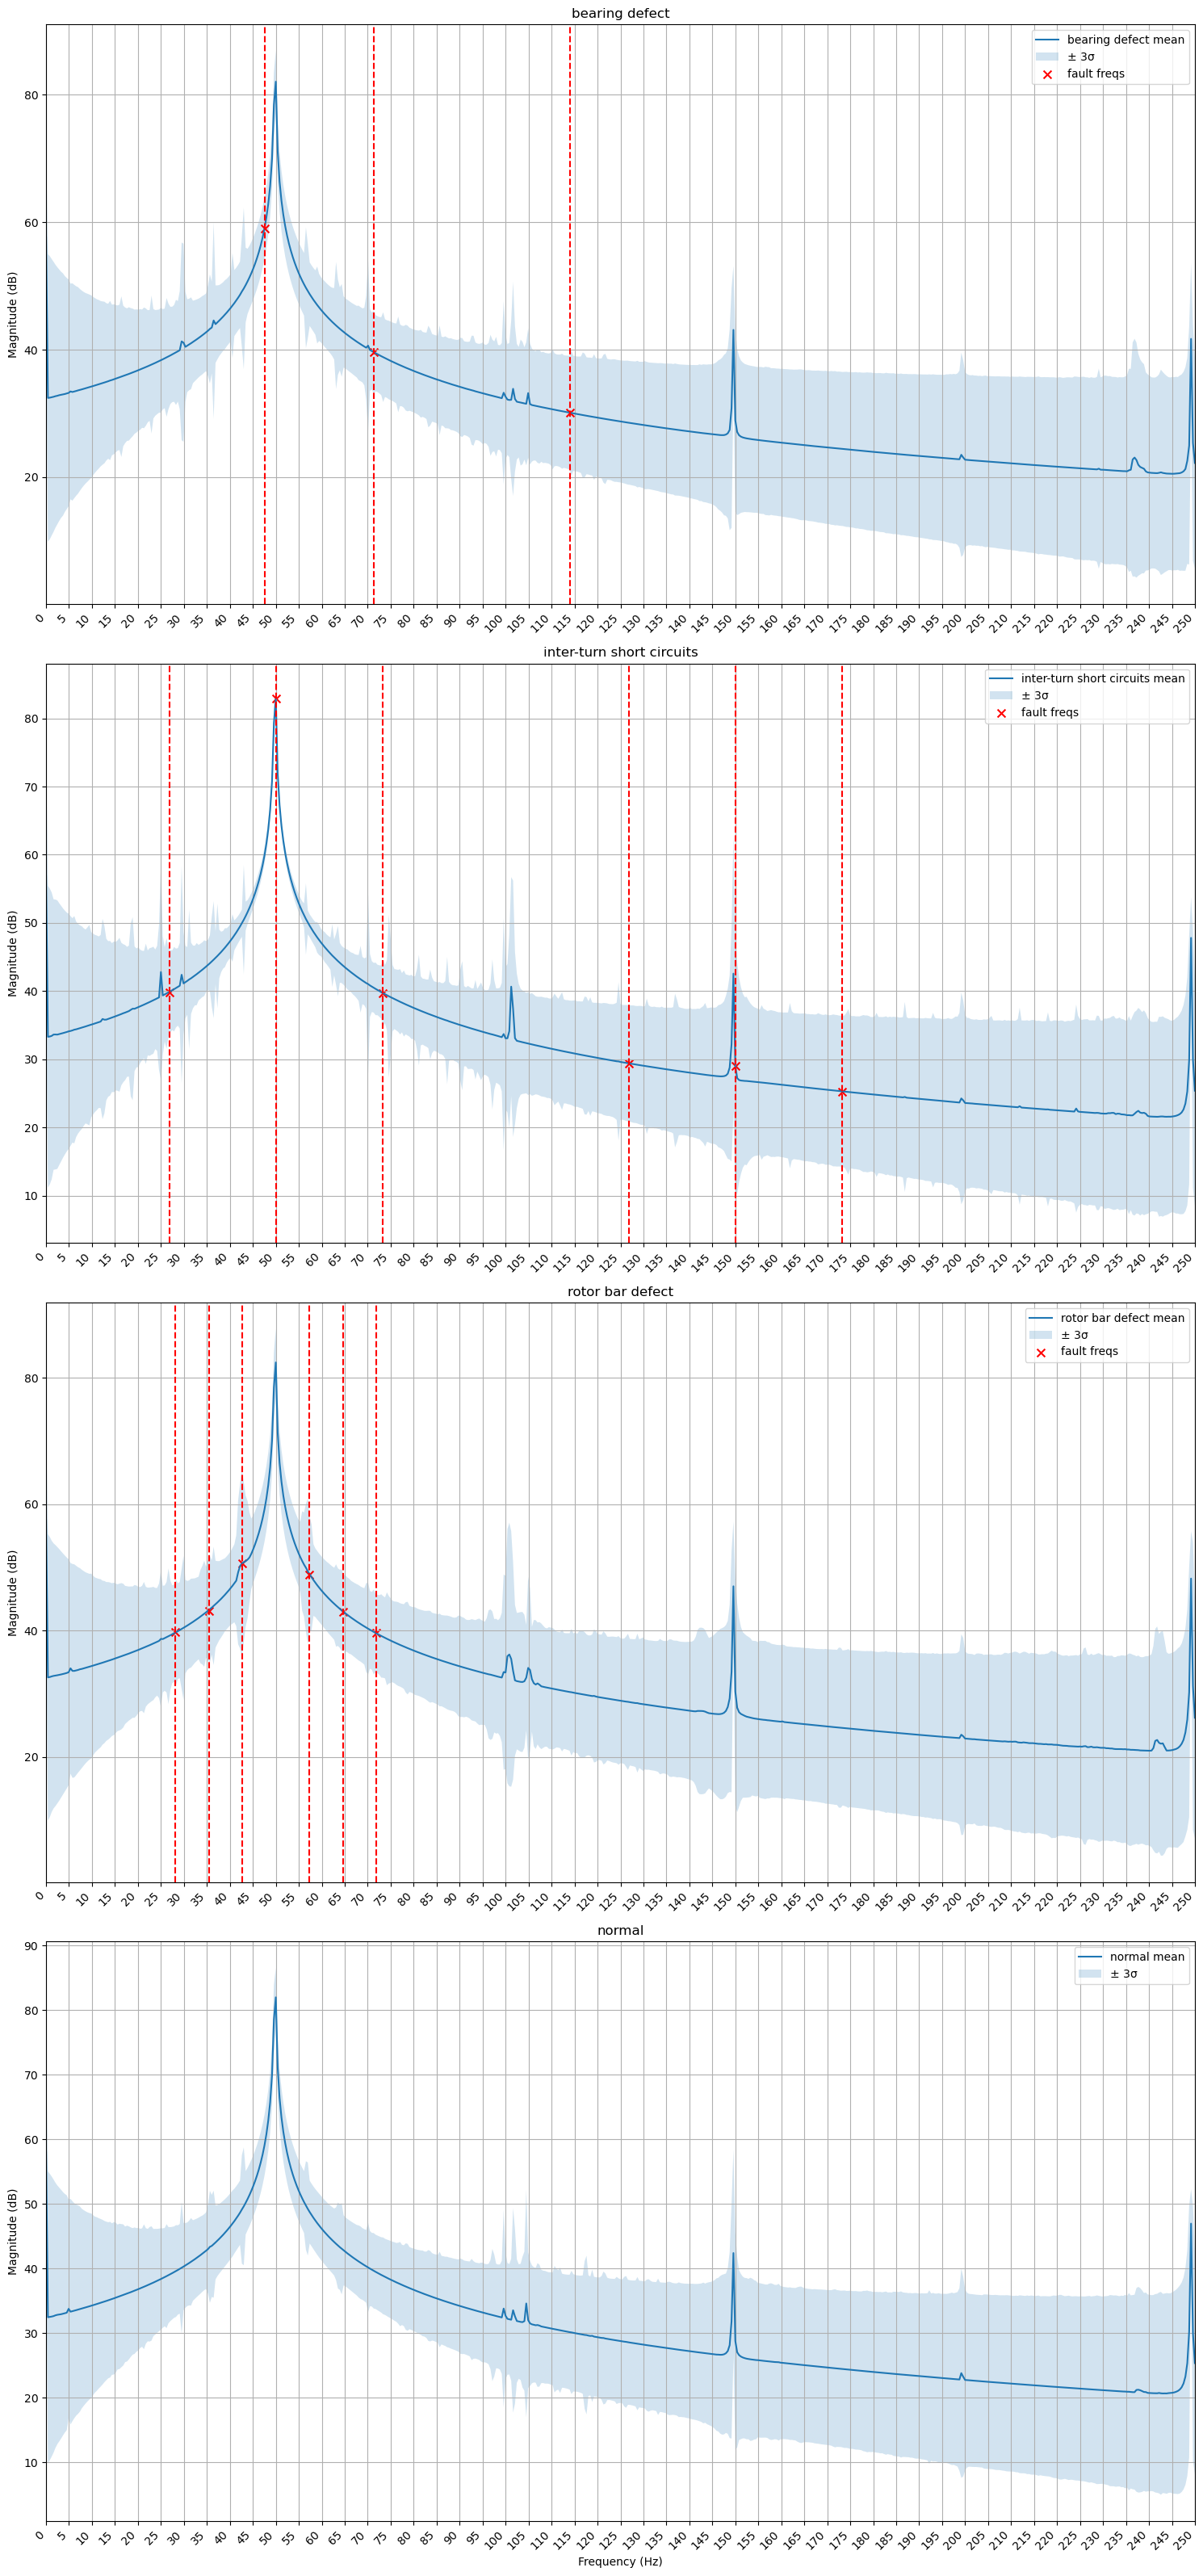

In [60]:
from matplotlib.ticker import MaxNLocator
n_xticks = len(freqs) / 10

def plot_mean_std_by_class(k=1, show_fault_freqs=False):
    states = seg_meta['state'].unique().tolist()
    n = len(states)
    fig, axs = plt.subplots(n, 1, figsize=(15, 8*n))
    
    for ax, state in zip(axs, states):
        mask       = seg_meta['state'] == state
        data       = segments[mask.values]
        mean_spec  = data.mean(axis=0)
        std_spec   = data.std(axis=0)
        
        # mean ± k*std
        ax.plot(freqs, mean_spec, label=f"{state} mean")
        ax.fill_between(
            freqs,
            mean_spec - k*std_spec,
            mean_spec + k*std_spec,
            alpha=0.2,
            label=f"± {k}σ"
        )
        
        # optional fault freqs
        if show_fault_freqs and state in fault_freqs:
            for f in fault_freqs[state]:
                ax.axvline(f, color='r', linestyle='--')
            # mark the band intersections
            ys = [ mean_spec[np.argmin(np.abs(freqs - f))] for f in fault_freqs[state] ]
            ax.scatter(fault_freqs[state], ys, color='r', marker='x', s=50, label="fault freqs")
        
        ax.set_xlim(np.floor(freqs[0]), np.ceil(freqs[-1]))
        ax.set_title(state)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=n_xticks, integer=True, prune=None))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right") 
        ax.set_ylabel("Magnitude (dB)")
        ax.legend(loc="upper right")
        ax.grid()
    
    axs[-1].set_xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

plot_mean_std_by_class(k=3, show_fault_freqs=True)

### Load Study

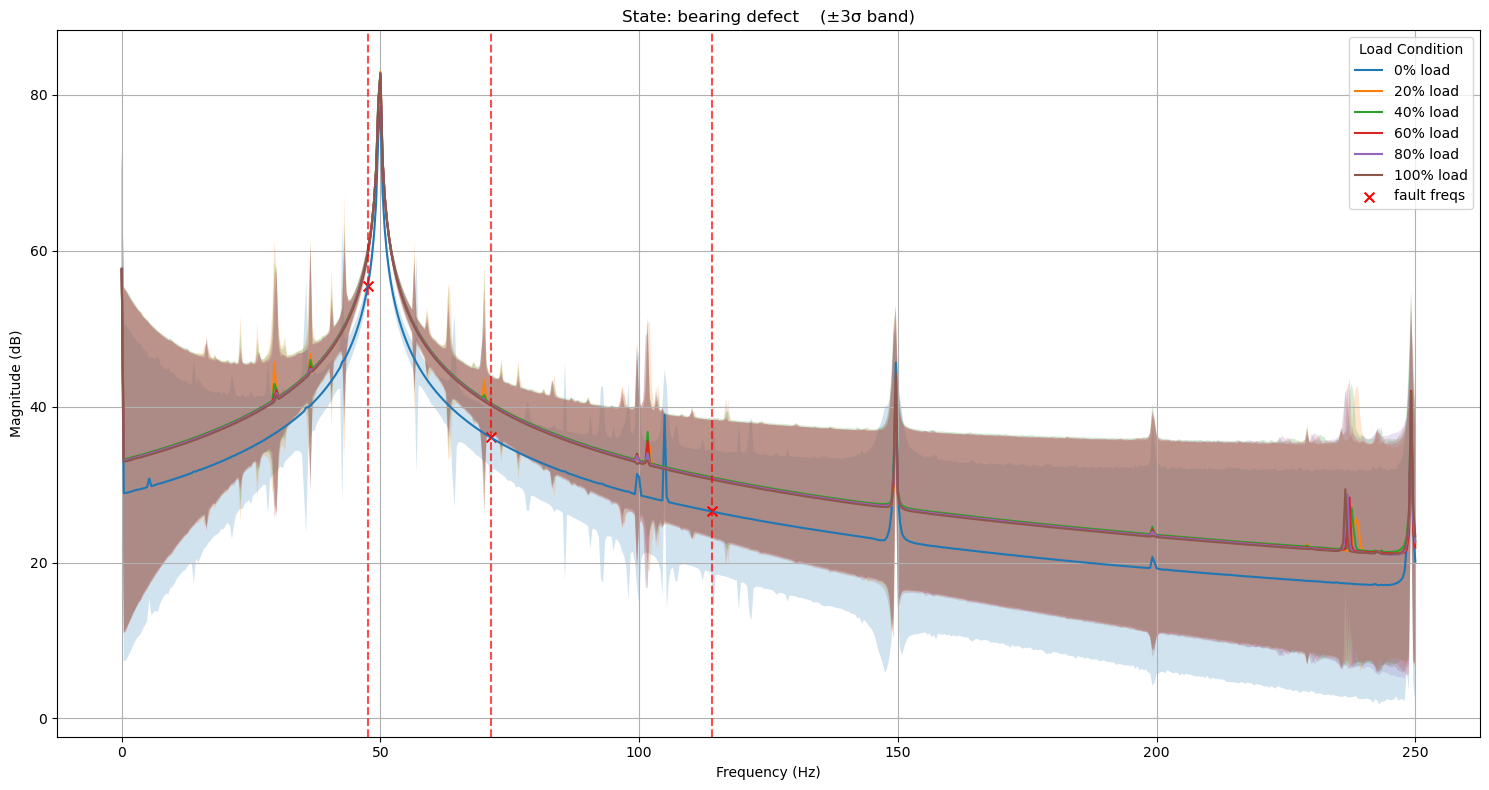

In [30]:
def plot_state_by_load(state_name, k=1, show_fault_freqs=False):
    """
    For one state, plot mean ± k·std curves for each load_condition,
    and overlay the state's fault frequencies if requested.
    """
    # filter to this state
    mask_state = (seg_meta['state'] == state_name)
    segs_state = segments[mask_state.values]        # only segments of the chosen state
    loads      = seg_meta.loc[mask_state, 'load_condition'].astype(str)
    
    unique_loads = sorted(loads.unique(), key=lambda x: float(x))
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # plot each load’s band
    for load in unique_loads:
        mask_load = (loads == load).values
        data = segs_state[mask_load]
        
        mean_spec = data.mean(axis=0)
        std_spec  = data.std(axis=0)
        
        ax.plot(freqs, mean_spec, label=f"{load}% load")
        ax.fill_between(
            freqs,
            mean_spec - k*std_spec,
            mean_spec + k*std_spec,
            alpha=0.2
        )
    
    # overlay fault frequencies (vertical lines + markers)
    if show_fault_freqs and state_name in fault_freqs:
        # vertical lines
        for f in fault_freqs[state_name]:
            ax.axvline(f, color='r', linestyle='--', alpha=0.7)
        # compute a baseline mean (e.g. at first load) from segs_state
        first_load = unique_loads[0]
        data0      = segs_state[loads == first_load]
        mean0      = data0.mean(axis=0)
        y_vals     = [ mean0[np.argmin(np.abs(freqs - f))] for f in fault_freqs[state_name] ]
        ax.scatter(fault_freqs[state_name], y_vals,
                   color='r', marker='x', s=50, label='fault freqs')
    
    ax.set_title(f"State: {state_name}    (±{k}σ band)")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.legend(title="Load Condition", loc="upper right")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_state_by_load("bearing defect", k=3, show_fault_freqs=True)

In [31]:
state_name = "inter-turn short circuits"

mask_state = (seg_meta['state'] == state_name)
segs_state = segments[mask_state.values]
loads_series = seg_meta.loc[mask_state, 'load_condition']

sorted(loads_series.unique(), key=lambda x: float(x))

[60, 80, 100]

In [32]:
from scipy.signal import find_peaks

def detect_peaks(
    freqs: np.ndarray,
    mags:  np.ndarray,
    height:     float = None,
    prominence: float = None,
    distance:   int   = None
) -> tuple[np.ndarray, np.ndarray]:
    """
    Detects peaks in the spectrum.

    Parameters
    ----------
    freqs : 1D array of frequency bins (Hz)
    mags  : 1D array of magnitudes (dB or linear)
    height : float, optional
        Minimum peak height.
    prominence : float, optional
        Minimum prominence of peaks.
    distance : int, optional
        Minimum number of bins between adjacent peaks.

    Returns
    -------
    peak_freqs : array of frequencies at detected peaks
    peak_mags  : array of magnitudes at detected peaks
    """
    if find_peaks is not None:
        # Use scipy if available
        peaks, props = find_peaks(
            mags,
            height=height,
            prominence=prominence,
            distance=distance
        )
    else:
        # Simple NumPy-based local maxima
        # peak if greater than neighbors and above height
        peaks = []
        N = len(mags)
        for i in range(1, N-1):
            if mags[i] > mags[i-1] and mags[i] > mags[i+1]:
                if (height is None or mags[i] >= height):
                    peaks.append(i)
        peaks = np.array(peaks, dtype=int)
        props = {}

    peak_freqs = freqs[peaks]
    peak_mags  = mags[peaks]
    return peak_freqs, peak_mags


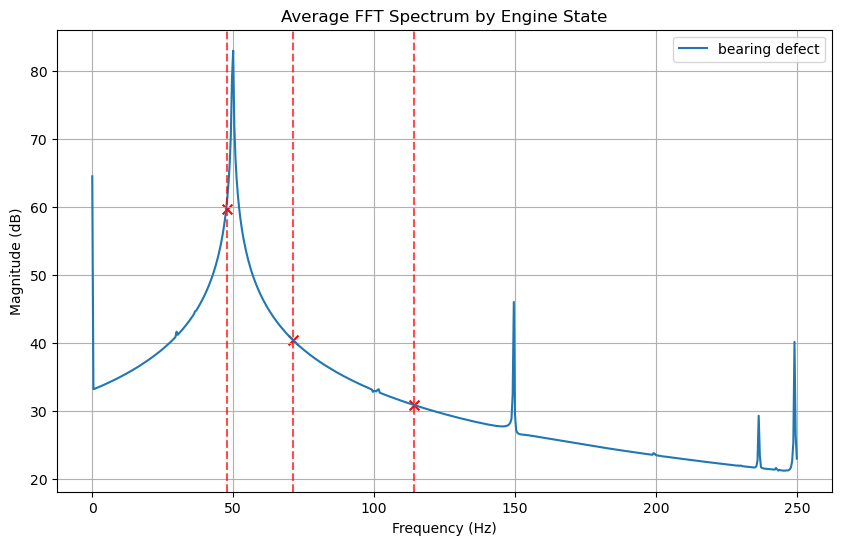

Top 5 Peaks:
50.0 Hz → 82.98 dB
149.6 Hz → 45.99 dB
249.2 Hz → 40.13 dB
236.5 Hz → 29.25 dB


In [33]:
state_name = "bearing defect"

mask = filter_segments(
    seg_meta,
    states=[state_name],
    loads=[100],
    phases=[1]
)

masked_segments = segments[mask.values]
mean_segment = masked_segments.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(freqs, mean_segment, label=state_name)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Average FFT Spectrum by Engine State")
ax.legend()
ax.grid(True)

if True and state_name in fault_freqs:
    for f in fault_freqs[state_name]:
        ax.axvline(f, color='r', linestyle='--', alpha=0.7)
    # use the first selected load to pick y‐positions for the markers
    first = 100
    baseline = segs_state[loads_series == first]
    mean0    = baseline.mean(axis=0)
    ys       = [mean0[np.argmin(np.abs(freqs - f))] for f in fault_freqs[state_name]]
    ax.scatter(fault_freqs[state_name], ys,
                color='r', marker='x', s=50, label='fault freqs')

plt.show()

# Suppose `freqs, mean_spec` from your FFT:
peak_freqs, peak_mags = detect_peaks(
    freqs, mean_segment,
    height=0,        # only peaks above –20 dB
    prominence=3,      # peaks standing ≥3 dB above neighbors
    distance=5         # at least 5 bins apart
)

# Print top 5 peaks
print('Top 5 Peaks:')
for f, m in sorted(zip(peak_freqs, peak_mags), key=lambda x: -x[1])[:5]:
    print(f"{f:.1f} Hz → {m:.2f} dB")

### Fault vs FF

For given load, phase and state plot mean ± k·std curves with fault frequencies

In [46]:
def plot_mean_std_with_freqs(segments, freqs, state_name, fault_freqs, k=3):
    ax = plot_mean_std(mean_spec=segments.mean(axis=0),
                            std_spec=segments.std(axis=0), 
                            freqs=freqs, 
                            k=k)

    plot_fault_freqs(ax, fault_freqs, state_name)
    return ax

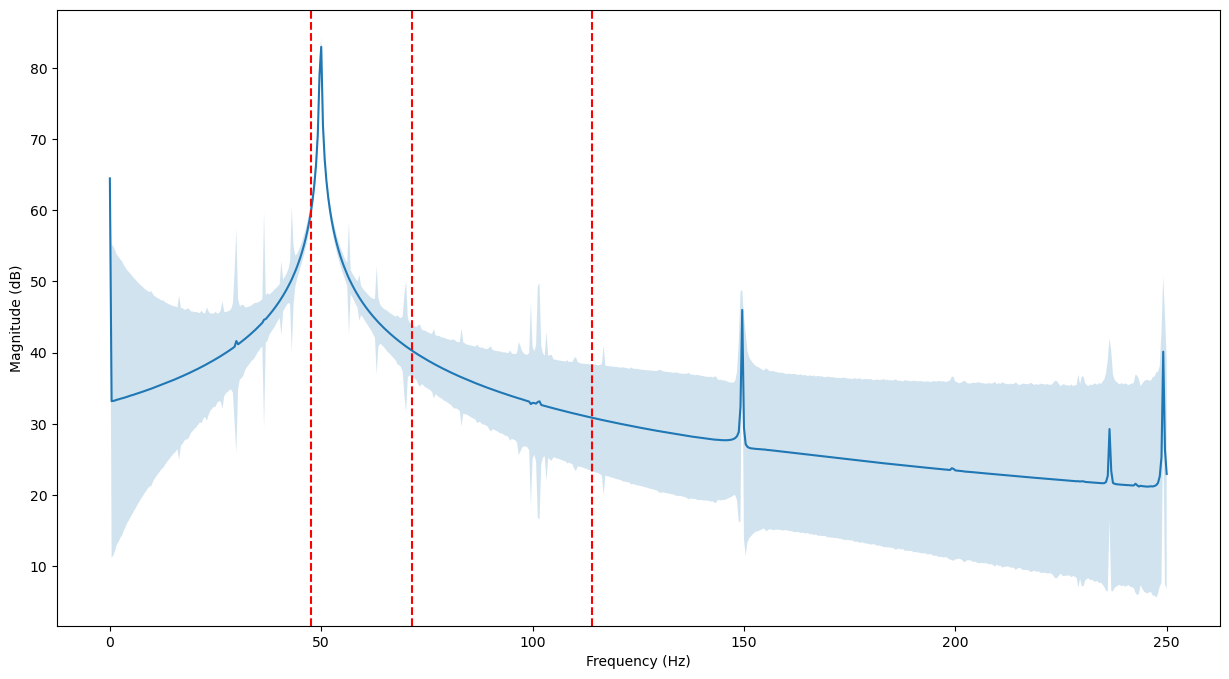

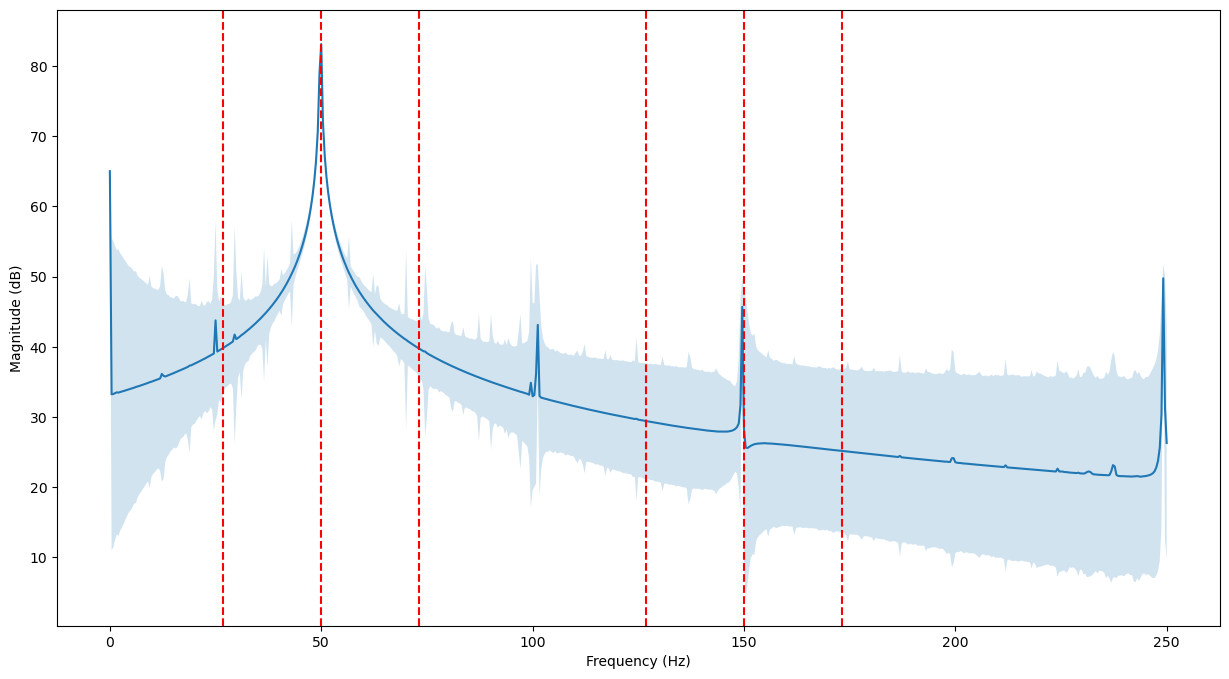

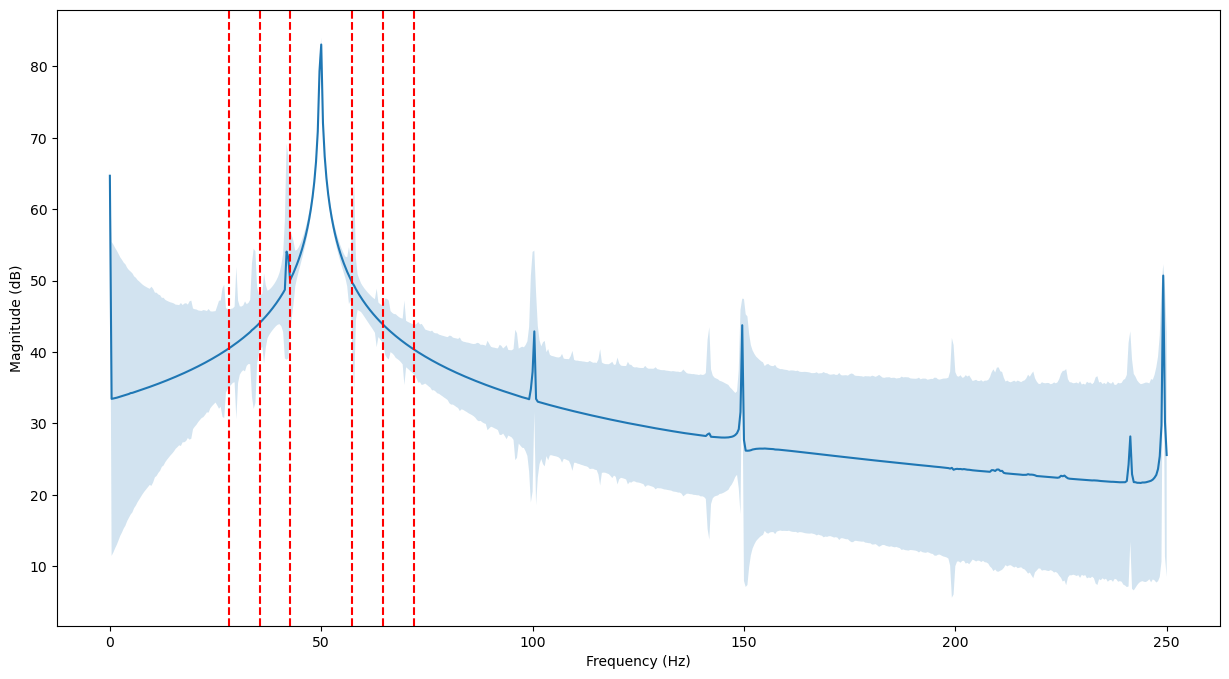

In [47]:
loads = [100]
phases=[1]

for state_name in fault_types_available:
    mask = filter_segments(
    seg_meta,
    states=[state_name],
    loads=loads,
    phases=phases
    )

    masked_segments = segments[mask.values]
    plot_mean_std_with_freqs(masked_segments, freqs, state_name, fault_freqs, k=3)
    plt.show()

### Structural Deviations

For given load, phase and fault state plot mean ± k·std curves for differences between amplitudes of the fault state and normal one with fault frequencies.

In [48]:
fault_short_name = {
    'inter-turn short circuits': 'ITSC',
    'bearing defect': 'BD',
    'rotor bar defect': 'RBD'
}

In [49]:
def plot_structural_deviations_with_freqs(segments, seg_meta, freqs, fault_freqs, target_state, loads, phases, k_sigma=3, ax=None):
    if ax is None:
        ax = plot_structural_deviations(segments, seg_meta, freqs, target_state, loads, phases, k_sigma=k_sigma)
    else:
        ax = plot_structural_deviations(segments, seg_meta, freqs, target_state, loads, phases, k_sigma=k_sigma, ax=ax)
    
    ax = plot_fault_freqs(ax, fault_freqs, target_state)
    ax.set_title(f"Mean difference between {target_state} and normal")
    ax.legend(['Mean', f'{k_sigma}*σ', f'{fault_short_name[target_state]} FF'])
    ax.grid()
    ax.set_xlim(np.floor(freqs[0]), np.ceil(freqs[-1]))
    return ax

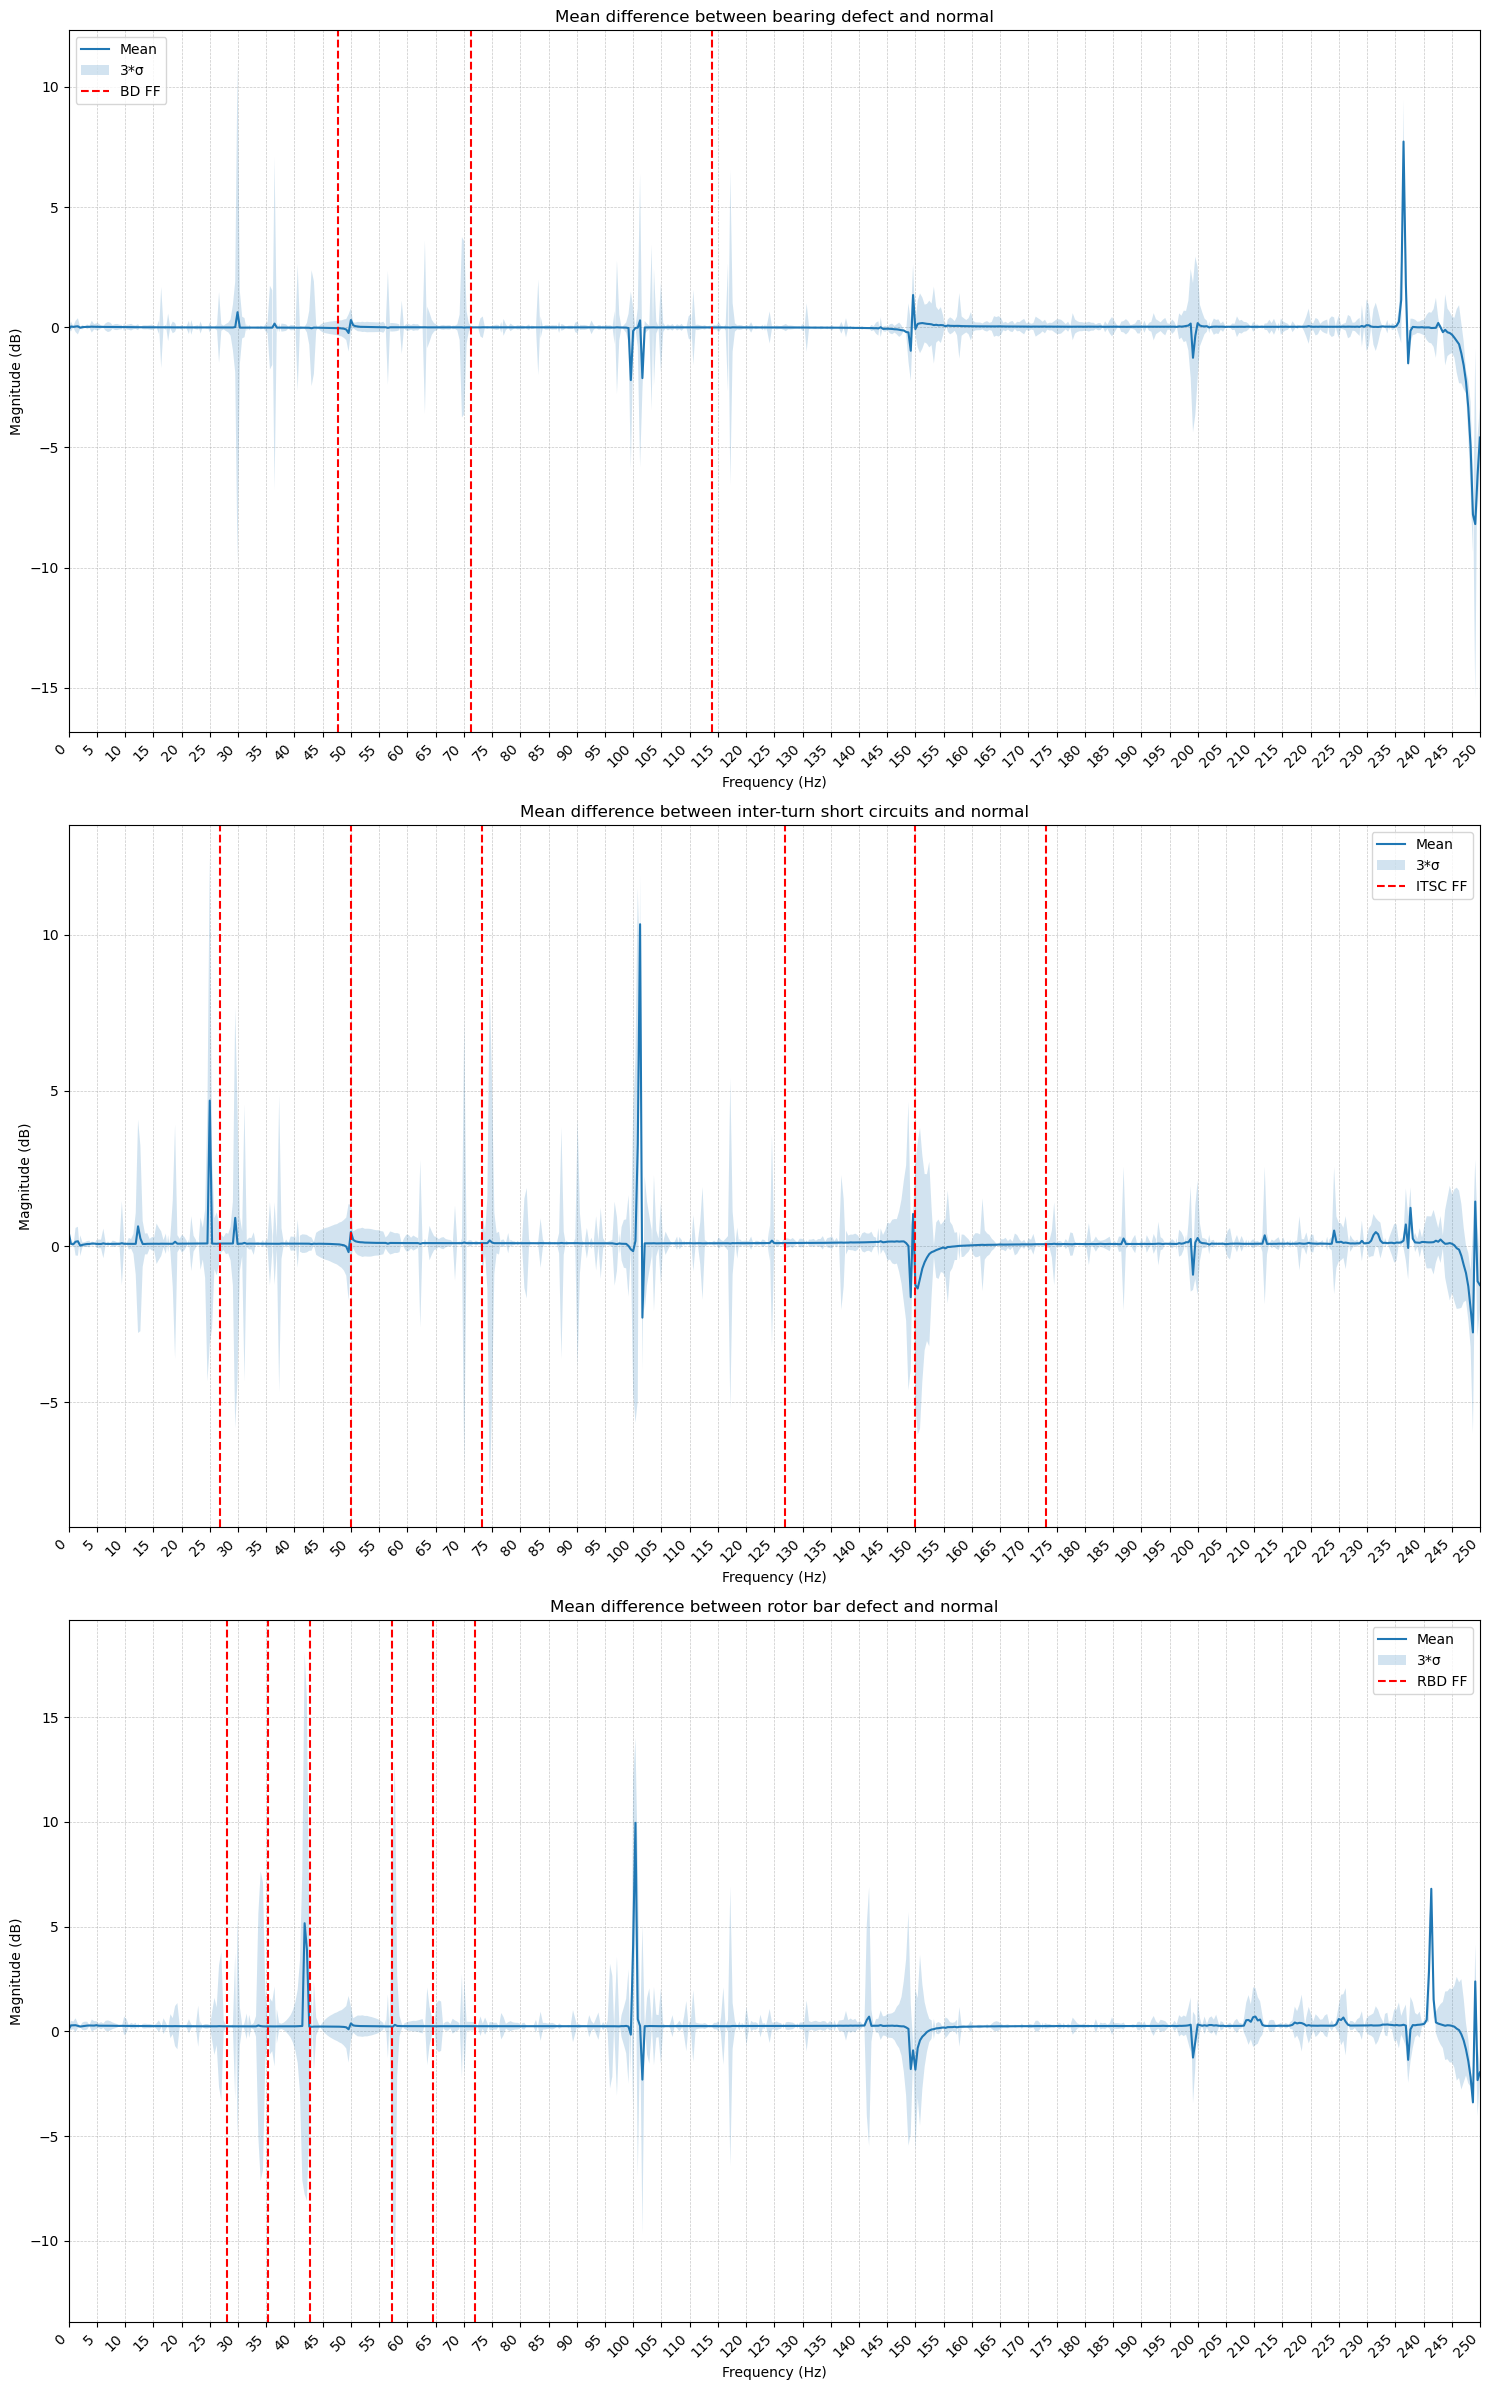

In [50]:
from matplotlib.ticker import MaxNLocator
n_xticks = len(freqs) // 10

loads = [100]
phases = [1]

n = len(fault_types_available)
fig, axs = plt.subplots(n, 1, figsize=(15, 8*n))

for ax, target_state in zip(axs, states):
    ax = plot_structural_deviations_with_freqs(segments, seg_meta, freqs, fault_freqs, target_state, loads, phases, k_sigma=3, ax=ax)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=n_xticks, integer=True, prune=None))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right") 
    ax.set_ylabel("Magnitude (dB)")
    
    # Grid behind the data, styled for visibility
    ax.set_axisbelow(True)
    ax.grid(
        True, which='major', axis='both',
        linestyle='--', linewidth=0.5, alpha=0.7
    )

axs[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

It seems that using only one segment without considering dynamic characteristics of a signal, detection of faults is quite difficult or maybe even impossible in a case of bearing faults. The predicted FF do not correspond to any area of non-zero mean or high variability. 

For ITSC and RBD the situation is slightly better.

In [57]:
seg_meta

start_time  end_time             state  \
measurement_id segment_idx                                           
0              0                   0.0    9999.0            normal   
               1                  20.0   10019.0            normal   
               2                  40.0   10039.0            normal   
               3                  60.0   10059.0            normal   
               4                  80.0   10079.0            normal   
...                                ...       ...               ...   
2              4496            89920.0   99919.0  rotor bar defect   
               4497            89940.0   99939.0  rotor bar defect   
               4498            89960.0   99959.0  rotor bar defect   
               4499            89980.0   99979.0  rotor bar defect   
               4500            90000.0   99999.0  rotor bar defect   

                            binary_label  multiclass_label  phase  \
measurement_id segment_idx                                          
0              0                       0            normal      1   
               1                       0            normal      1   
               2                       0            normal      1   
               3                       0            normal      1   
               4                       0            normal      1   
...                                  ...               ...    ...   
2              4496                    1  rotor bar defect      1   
               4497                    1  rotor bar defect      1   
               4498                    1  rotor bar defect      1   
               4499                    1  rotor bar defect      1   
               4500                    1  rotor bar defect      1   

                            load_condition    experiment  
measurement_id segment_idx                                
0              0                       NaN  experiment_3  
               1                       NaN  experiment_3  
               2                       NaN  experiment_3  
               3                       NaN  experiment_3  
               4                       NaN  experiment_3  
...                                    ...           ...  
2              4496                    NaN  experiment_2  
               4497                    NaN  experiment_2  
               4498                    NaN  experiment_2  
               4499                    NaN  experiment_2  
               4500                    NaN  experiment_2  

[11003 rows x 8 columns]

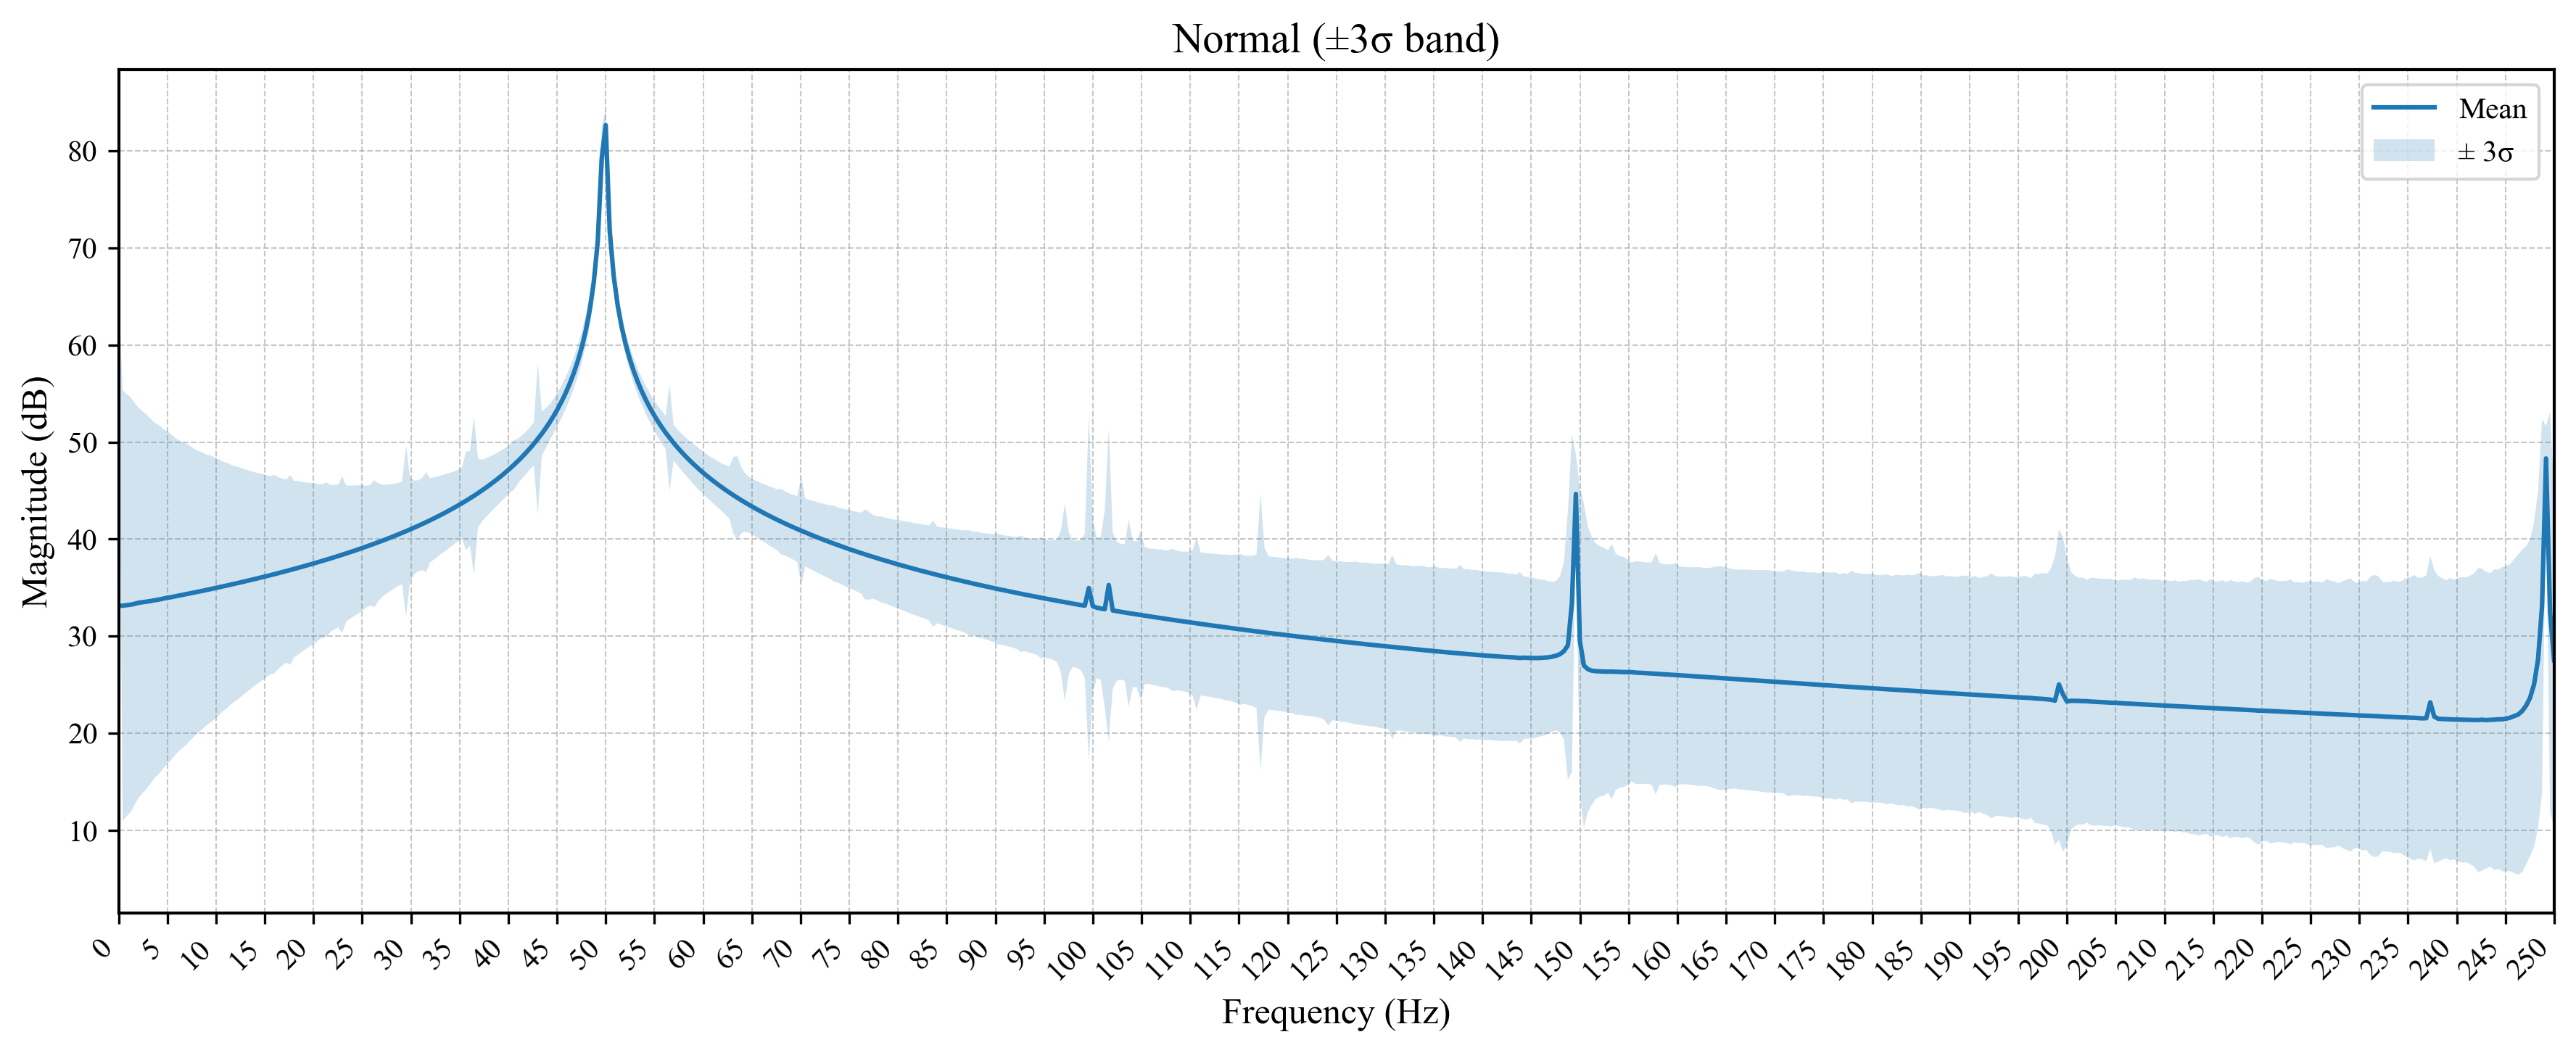

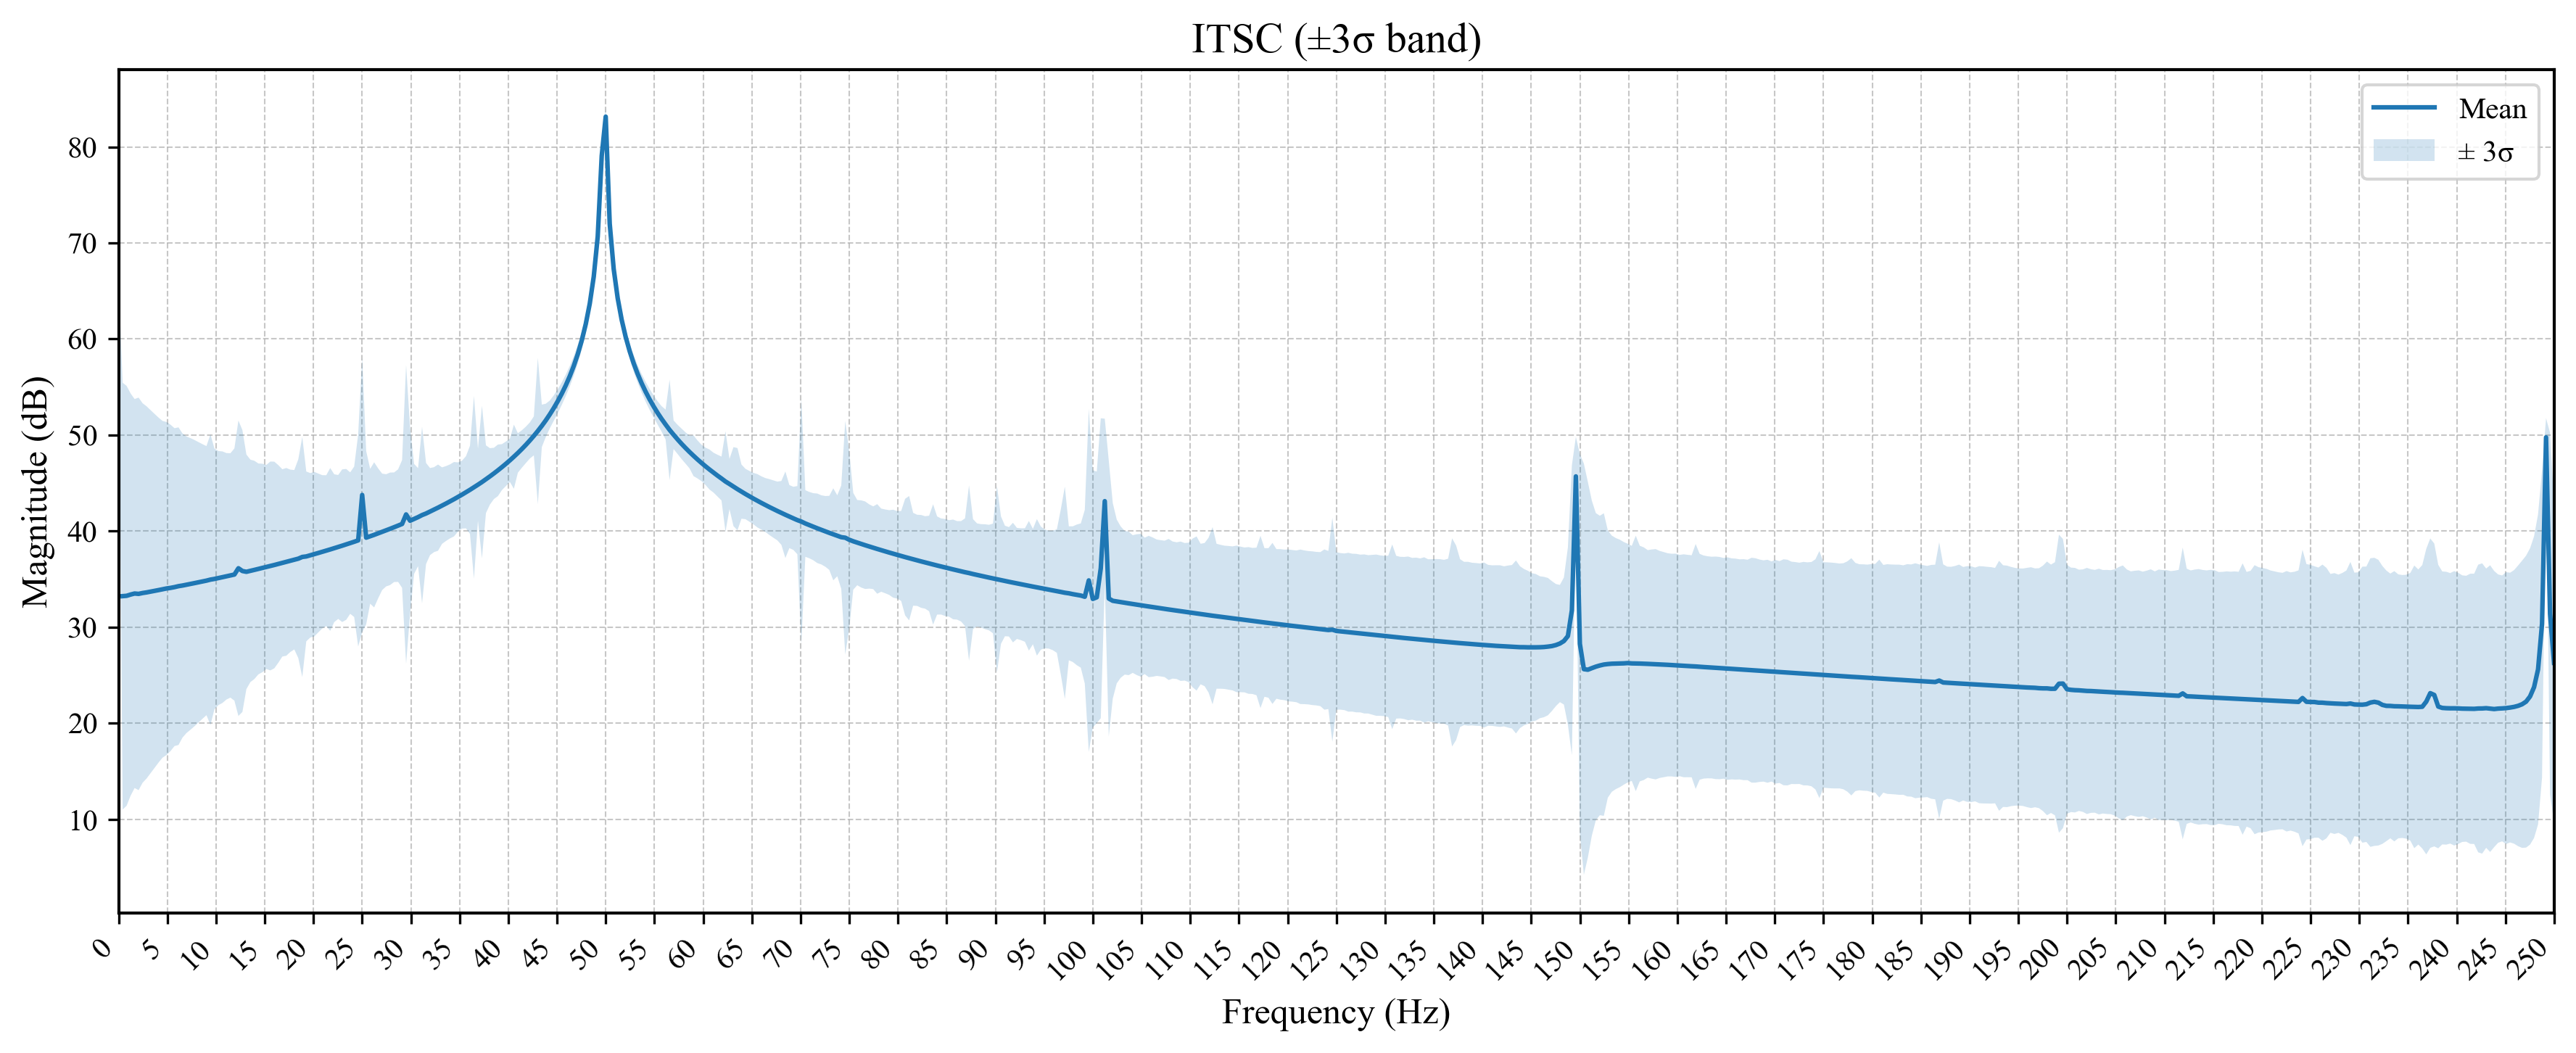

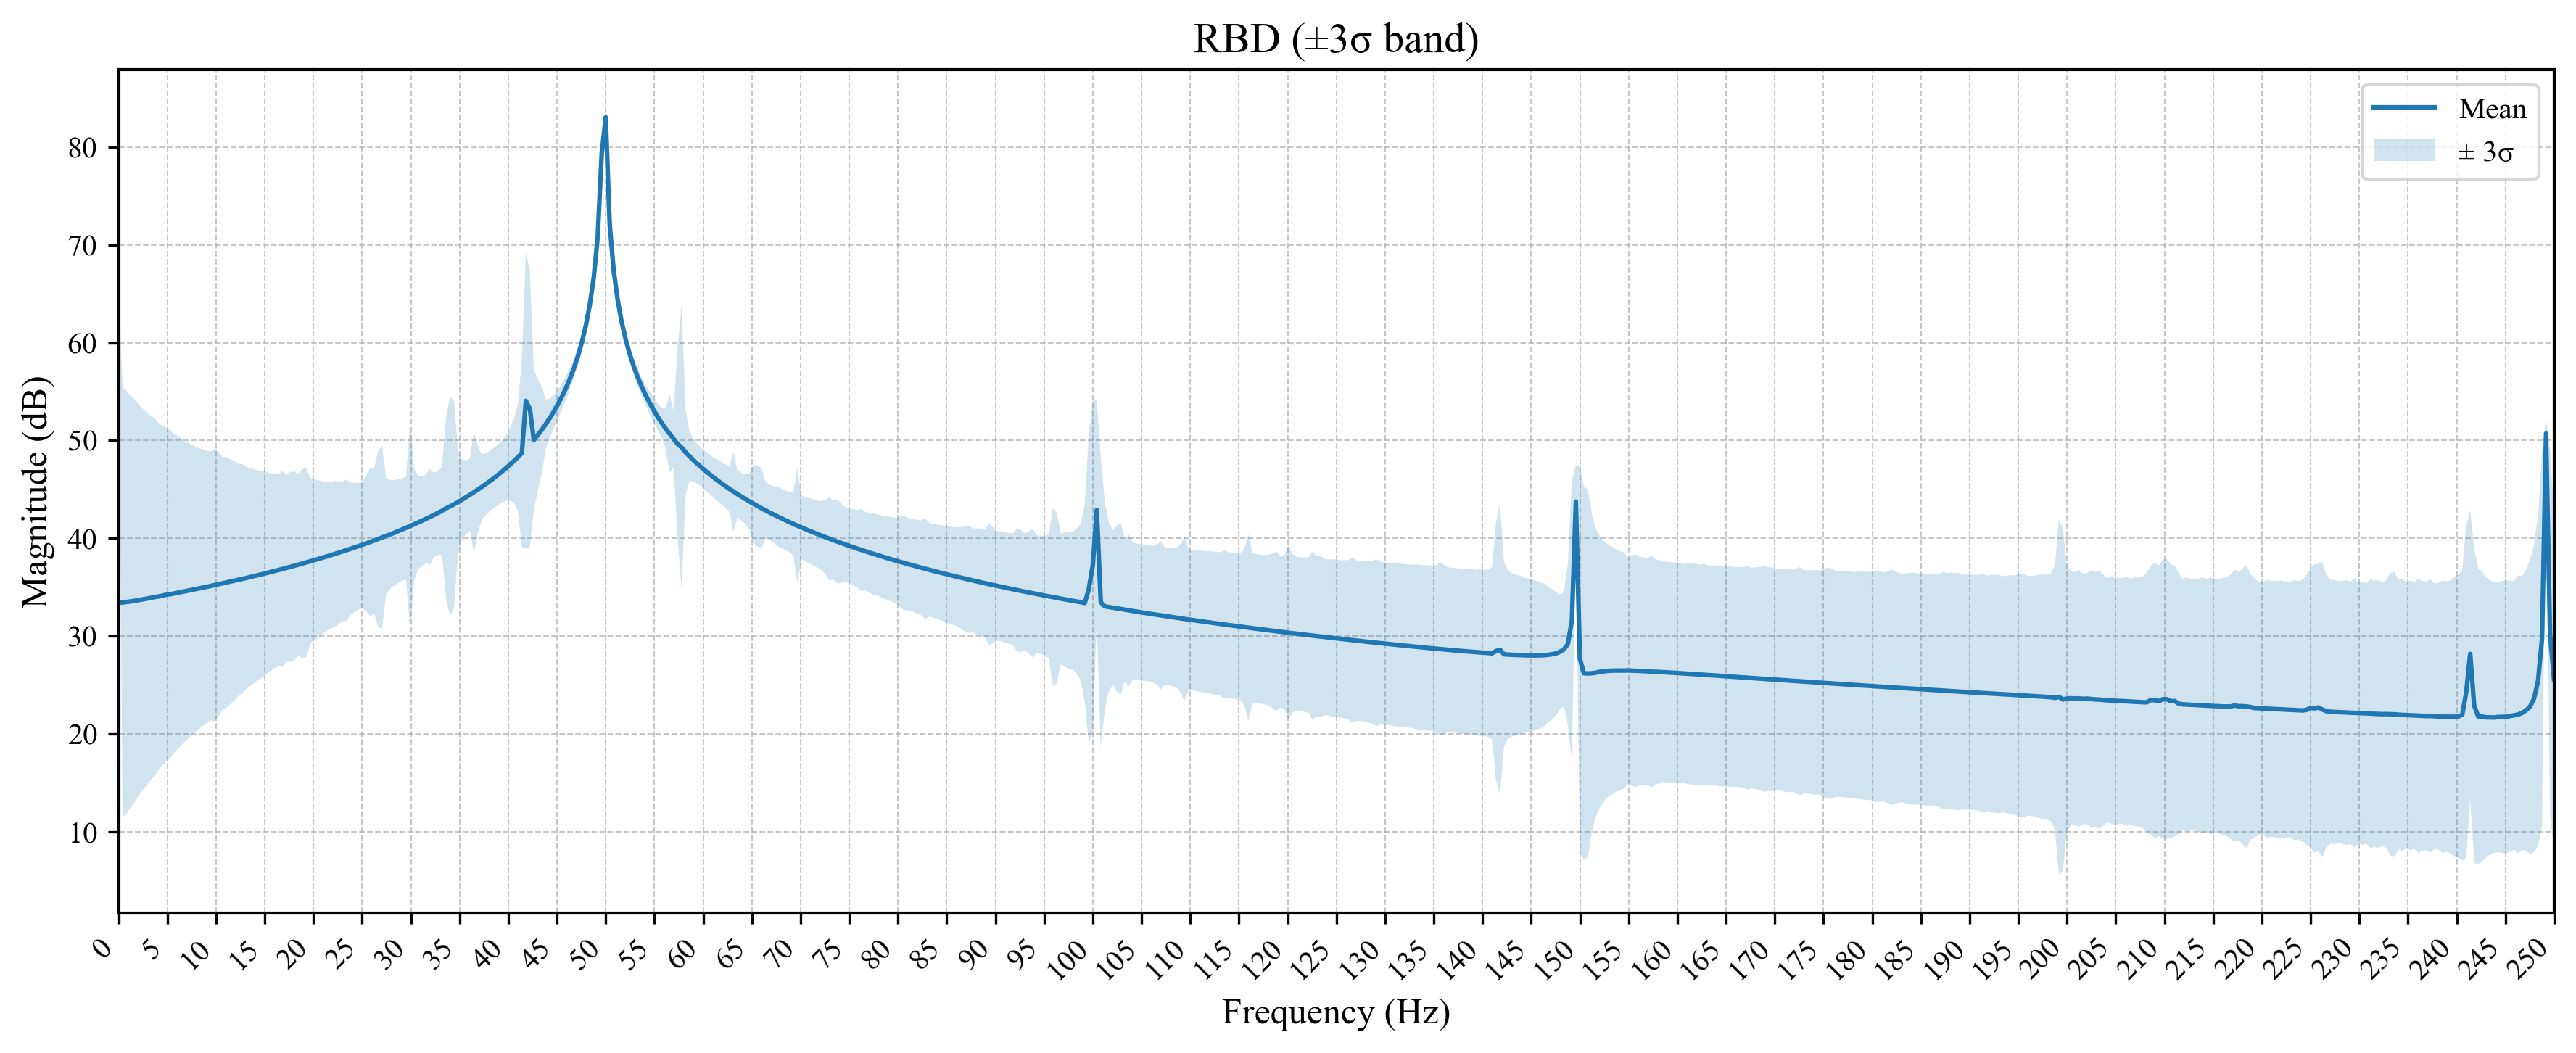

In [69]:
# === Separate mean ± k·std plots for Normal, ITSC, and RBD ===

from src.visualization import filter_segments  # if not already imported
import matplotlib.pyplot as plt

states_to_plot = [
    "normal",
    "inter-turn short circuits",  # ITSC
    "rotor bar defect"            # RBD
]
loads     = [100]
phases    = [1]
k_sigma   = 3

state2label = {
    "normal": "Normal",
    "inter-turn short circuits": "ITSC",
    "rotor bar defect": "RBD"
}

for state in states_to_plot:
    # 1) filter segments for this state
    mask = filter_segments(seg_meta, states=[state], loads=loads, phases=phases)
    data = segments[mask.values]

    # 2) compute mean and std
    mean_spec = data.mean(axis=0)
    std_spec  = data.std(axis=0)

    # 3) plot in a standalone figure
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(freqs[1:], mean_spec[1:], label=f"Mean")
    ax.fill_between(
        freqs,
        mean_spec - k_sigma*std_spec,
        mean_spec + k_sigma*std_spec,
        alpha=0.2,
        label=f"± {k_sigma}σ"
    )
    
    ax.xaxis.set_major_locator(MaxNLocator(nbins=n_xticks, integer=True, prune=None))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right") 
    ax.set_ylabel("Magnitude (dB)")
    
    # Grid behind the data, styled for visibility
    ax.set_axisbelow(True)
    ax.grid(
        True, which='major', axis='both',
        linestyle='--', linewidth=0.5, alpha=0.7
    )
    ax.set_xlim(np.floor(freqs[0]), np.ceil(freqs[-1]))

    ax.set_title(f"{state2label[state]} (±{k_sigma}σ band)")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.legend(loc="upper right")
    ax.grid(True)
    plt.tight_layout()

    # —–– SAVE –––––
    fname = state.replace(" ", "_").replace("-", "").lower()
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches='tight')
    fig.savefig(f"{fname}.pdf", dpi=300, bbox_inches='tight', format='pdf')
    plt.show()


## Old Data

In [51]:
base_dir = "../dataset/engine_1"

segments_path   = f"{base_dir}/segments.npy"
meta_path       = f"{base_dir}/segments_metadata.csv"
freqs_path      = f"{base_dir}/freqs.npy"

# Load
segments    = np.load(segments_path, mmap_mode="r")            # shape (n_segments, n_freq_bins)
seg_meta    = pd.read_csv(meta_path, index_col=["measurement_id", "segment_idx"])
freqs       = np.load(freqs_path)                              # length = n_freq_bins

# Classes
states = seg_meta['state'].unique()

# Load Engine Configuration
path2engine_cfg = os.path.join(base_dir, 'engine.yml')
with open(path2engine_cfg, 'r') as f:
    engine_config = yaml.safe_load(f)

fault_types_available = [state for state in states if state != 'normal']

fault_freqs = {
    fault_type: ANOMALY_FREQS[fault_type](**MCSA_cfg[fault_type]) for fault_type in fault_types_available
}

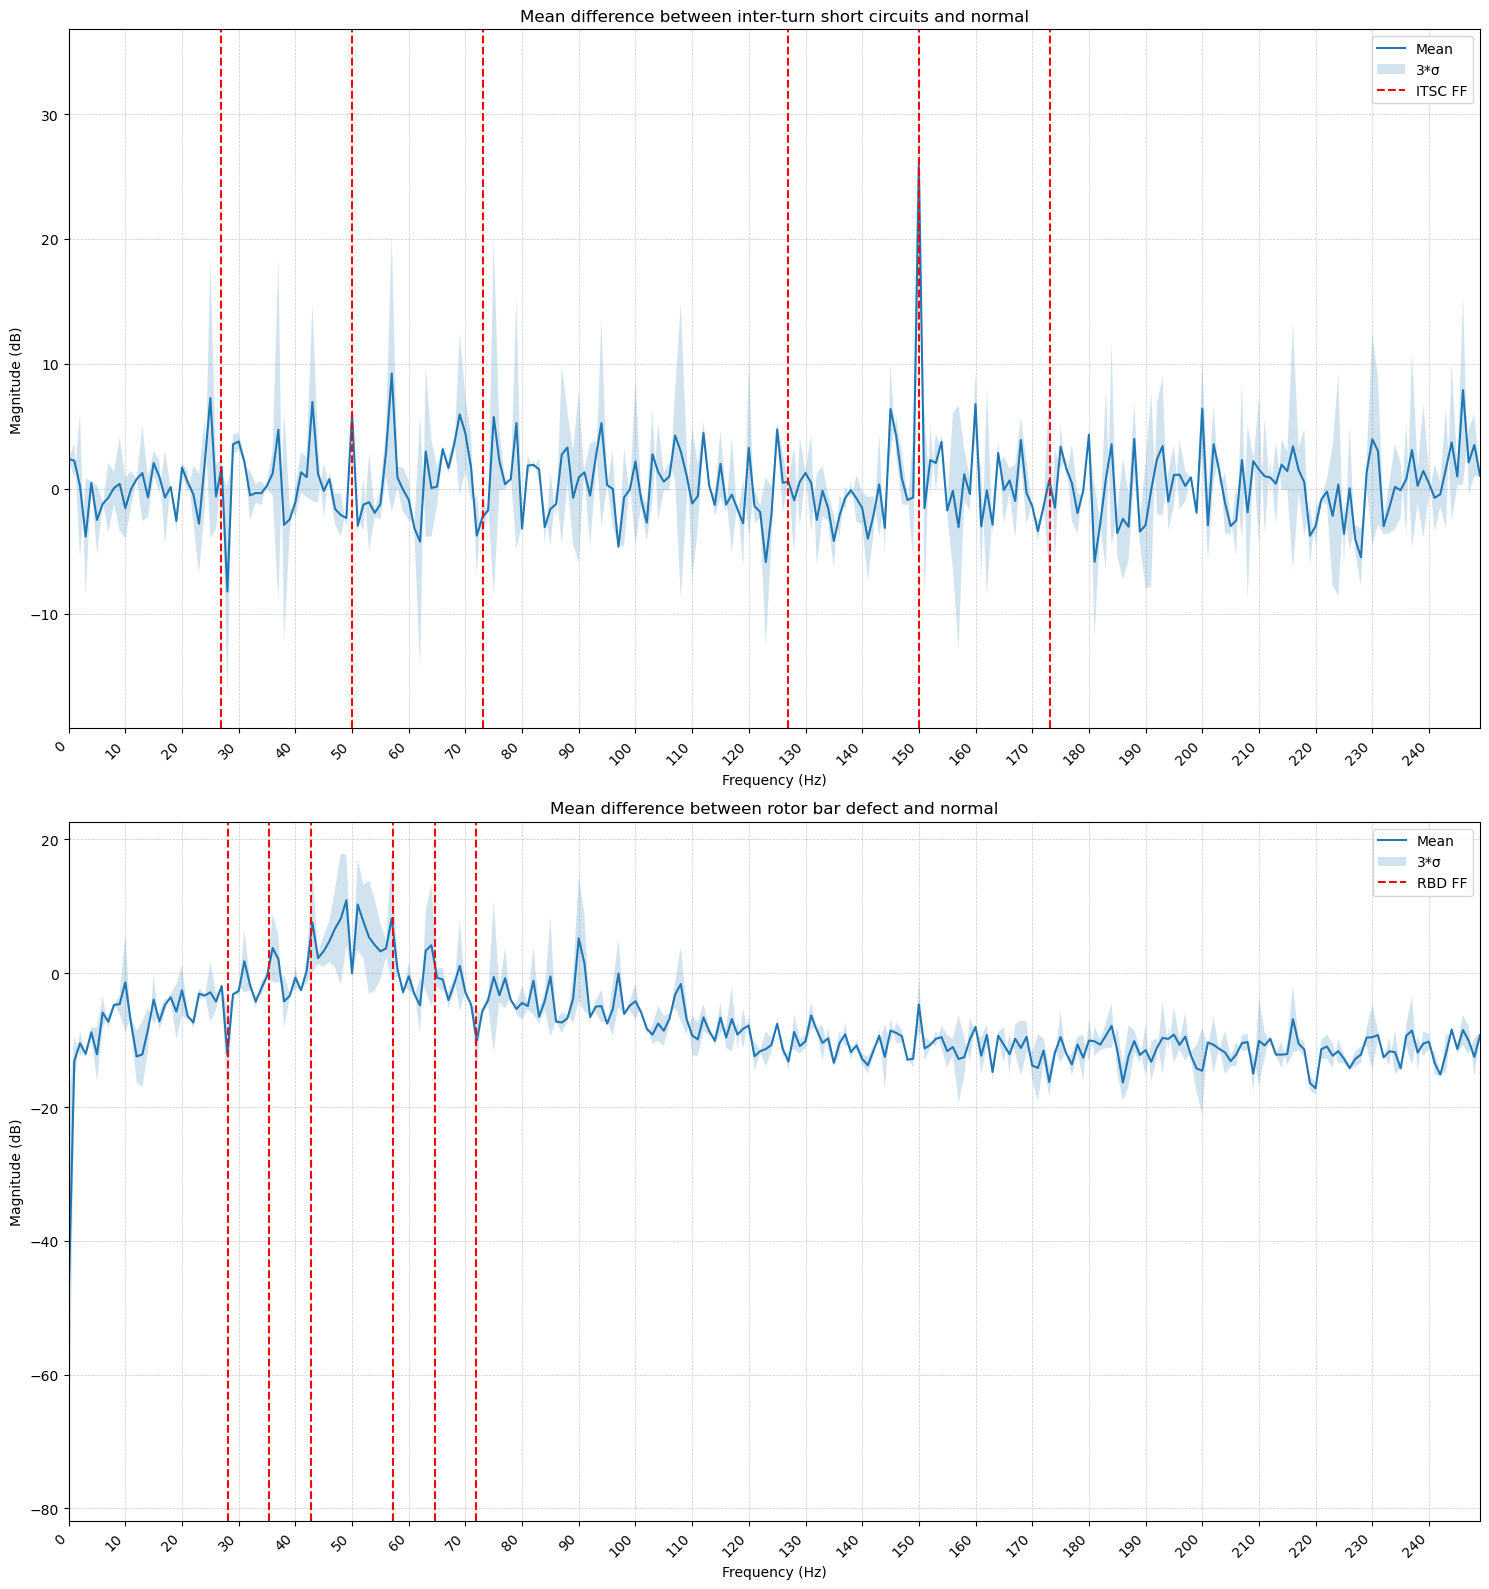

In [52]:
from matplotlib.ticker import MaxNLocator
n_xticks = len(freqs) // 10

loads = [np.nan]
phases = [1]

n = len(fault_types_available)
fig, axs = plt.subplots(n, 1, figsize=(15, 8*n))

for ax, target_state in zip(axs, fault_types_available):
    ax = plot_structural_deviations_with_freqs(segments, seg_meta, freqs, fault_freqs, target_state, loads, phases, k_sigma=3, ax=ax)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=n_xticks, integer=True, prune=None))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right") 
    ax.set_ylabel("Magnitude (dB)")
    
    # Grid behind the data, styled for visibility
    ax.set_axisbelow(True)
    ax.grid(
        True, which='major', axis='both',
        linestyle='--', linewidth=0.5, alpha=0.7
    )

axs[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

## Some Conclusions

1. Old Data works better of algorithm performance demonstration
2. We should consider peaks with negative intensity, that decrease amplitude.
3. We should take into account possible problems with New Data: potential unpredictability of BF.